<a href="https://colab.research.google.com/github/kluttamaguzi/Public-Projects/blob/main/IABAC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **INX Future Inc-Employee Performance Analysis.**

This project analyzes employee data to identify key factors affecting employee performance and build a predictive model to support hiring and performance management decisions.

## 1.**Project Summary**
Since the objective was to analyze employee performance data to identify key factors affecting performance and build a predictive model the following steps were taken;
- Problem Statement
- Data Loading
- Data Understanding
- Data preprocessing (handling categorical and numerical variables)
- Model building using Logistic Regression and Random Forest
- Model evaluation and selection
- Feature importance analysis to identify key drivers
- Insights
- Recommnedations
- Conclusion

## **2.Problem Statement**

INX Future Inc. has observed a decline in employee performance, leading to reduced client satisfaction. The objective of this project is to:

- Analyze employee data to identify key drivers of performance
- Determine top factors affecting employee performance
- Build a predictive model for employee performance
- Provide actionable recommendations

This aligns with the business requirement to improve performance without negatively impacting employee morale.

## **3.Data Loading**
Data loaded was loaded and manipulated using Pandas Library

In [1]:
import numpy as np
import pandas as pd
from io import BytesIO
import requests
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = "http://data.iabac.org/exam/p2/data/INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.8.xls"

headers = {"User-Agent": "Mozilla/5.0"}
response = requests.get(url, headers=headers)

data = pd.read_excel(BytesIO(response.content))

##

## **4.Data Understanding**
To appreciate the type, size, spread and completeness of the data, the following finctions were run;
- the head function     .head()
- the describe function .decribe()
- the shape function    .shape

In [3]:
data.describe()

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,36.918333,9.165833,2.89250,2.715833,65.981667,2.731667,2.067500,2.732500,2.665000,15.222500,2.725000,11.330000,2.785833,2.744167,7.077500,4.291667,2.194167,4.105000,2.948333
std,9.087289,8.176636,1.04412,1.090599,20.211302,0.707164,1.107836,1.100888,2.469384,3.625918,1.075642,7.797228,1.263446,0.699374,6.236899,3.613744,3.221560,3.541576,0.518866
min,18.000000,1.000000,1.00000,1.000000,30.000000,1.000000,1.000000,1.000000,0.000000,11.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,30.000000,2.000000,2.00000,2.000000,48.000000,2.000000,1.000000,2.000000,1.000000,12.000000,2.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000,3.000000
50%,36.000000,7.000000,3.00000,3.000000,66.000000,3.000000,2.000000,3.000000,2.000000,14.000000,3.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000,3.000000
75%,43.000000,14.000000,4.00000,4.000000,83.000000,3.000000,3.000000,4.000000,4.000000,18.000000,4.000000,15.000000,3.000000,3.000000,10.000000,7.000000,3.000000,7.000000,3.000000
max,60.000000,29.000000,5.00000,4.000000,100.000000,4.000000,5.000000,4.000000,9.000000,25.000000,4.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000,4.000000


The following was revealed by the describe function;

- The data had both numerical and categorical variables
- There were no missing values

In [4]:
data.shape

(1200, 28)

In [5]:
data.head()

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,...,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,...,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,...,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,...,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,...,4,10,1,3,2,2,2,2,No,3


## **5.Data Preprocessing**
To prepare data for model buiding the following preprocessing tasks were performed;
- Defined a data wrangling function that was used to drop the EmpNumber column since it added no value to the predictive power of the model.
- Categorical and numerical columns were identified
- Seaborn heatmap was used to detect the presence of multicolinearity

In [6]:
#Data wrangling
def data_wrangling(data):
  '''
  Perform data wrangling by;
  1. dropping no-value-add variables,

  '''
  #Drop EmpNumber because they are simply unique identifiers and they add no value to the predictive ability of the model
  data.drop(['EmpNumber'], axis=1, inplace = True)


  return data
df = data_wrangling(data)

In [7]:
df.head()

,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,...,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,...,4,10,2,2,10,7,0,8,No,3
1,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,...,4,20,2,3,7,7,1,7,No,3
2,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,...,3,20,2,3,18,13,1,12,No,4
3,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,...,2,23,2,2,21,6,12,6,No,3
4,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,...,4,10,1,3,2,2,2,2,No,3


In [8]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(include='number').columns

print("Categorical Columns:")
print(cat_cols)
print("\nNumerical Columns:")
print(num_cols)


Categorical Columns:
Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object')

Numerical Columns:
Index(['Age', 'DistanceFromHome', 'EmpEducationLevel',
       'EmpEnvironmentSatisfaction', 'EmpHourlyRate', 'EmpJobInvolvement',
       'EmpJobLevel', 'EmpJobSatisfaction', 'NumCompaniesWorked',
       'EmpLastSalaryHikePercent', 'EmpRelationshipSatisfaction',
       'TotalWorkExperienceInYears', 'TrainingTimesLastYear',
       'EmpWorkLifeBalance', 'ExperienceYearsAtThisCompany',
       'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager', 'PerformanceRating'],
      dtype='object')


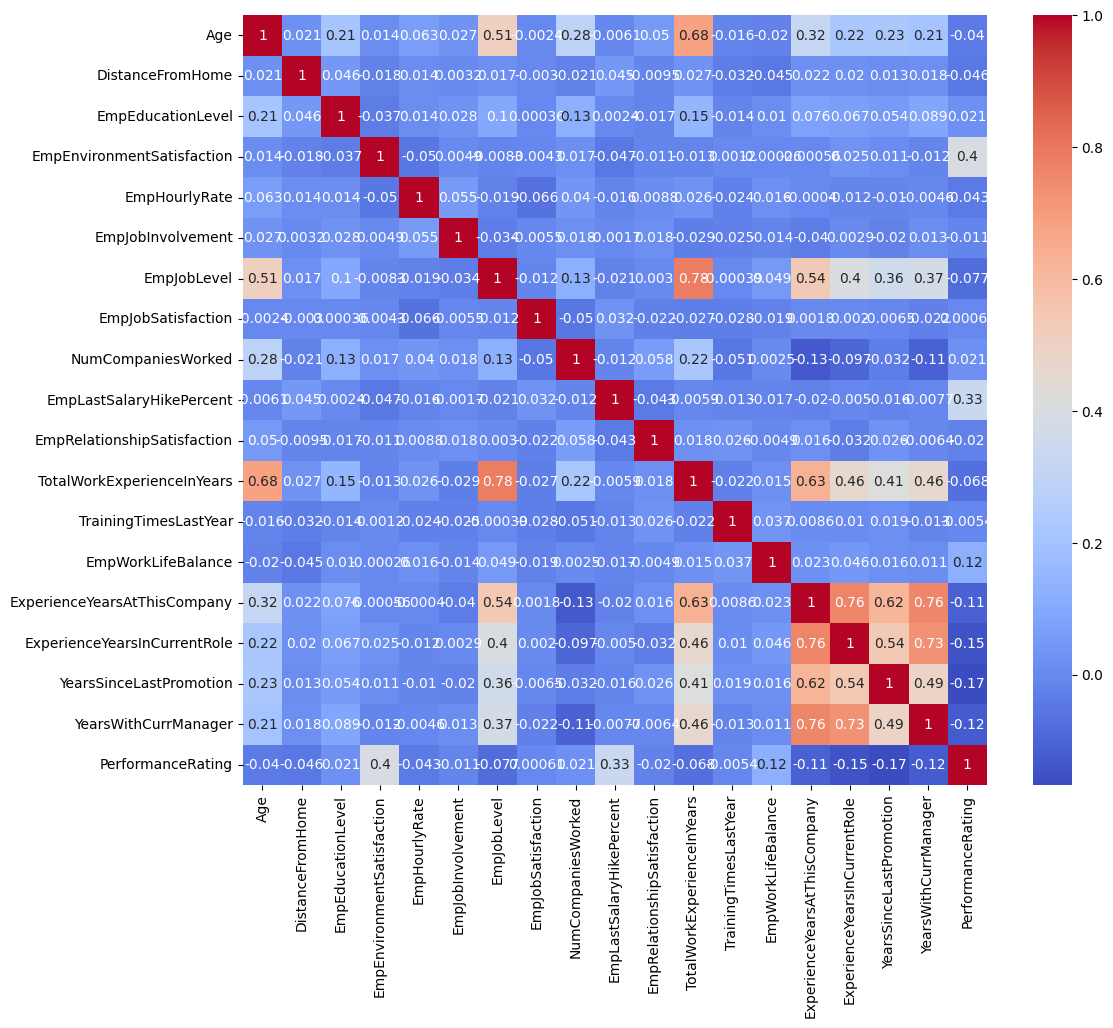

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
num_corr = df[num_cols].corr()
sns.heatmap(num_corr, annot=True, cmap='coolwarm')

plt.show()

Since none of the pair-wise correlations was greater or equal to **0.8**, it was concluded that there was no multicolinearity in the features.

## **6.Model Building**
Logistic Regression was used as a baseline model and Random Forest was used to capture non-linear relationships in the data

A pipeline was used to combine preprocessing and model training into a single workflow. This ensures consistent data transformation, prevents data leakage, and improves code organization and reproducibility.

In [10]:
from sklearn.model_selection import train_test_split

X = df.drop('PerformanceRating', axis=1)
y = df['PerformanceRating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

In [12]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


log_model = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('clf', LogisticRegression(max_iter=1000))])

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline([
    ('prep', preprocessor),
    ('clf', RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('clf', RandomForestClassifier(random_state=42))])

## **7.Model Evaluation and selection**

**7.1 Logistic Regression Vs Random Forest**

Random Forest was selected because it outperformed the baseline model (Logistic Regression)

Logistic Regression achieved an accuracy of 81%, serving as a baseline model. However, it showed limitations in capturing complex patterns, particularly in predicting certain performance classes.

Random Forest significantly outperformed Logistic Regression with an accuracy of 91% and higher F1-scores across all classes. This indicates the presence of non-linear relationships in the data, which are better captured by tree-based models.

Therefore, Random Forest was selected as the final model for predicting employee performance because it exhibited the ability to capture complex, intertwined and non-linear relationships which cannot be determined by linear models.

In [14]:
from sklearn.metrics import classification_report

# Logistic Regression predictions
log_pred = log_model.predict(X_test)

print("Logistic Regression Results:")
print(classification_report(y_test, log_pred))

#Random forest predictions
rf_pred = rf_model.predict(X_test)

print("Random Forest Results:")
print(classification_report(y_test, rf_pred))

Logistic Regression Results:
              precision    recall  f1-score   support

           2       0.58      0.59      0.59        49
           3       0.87      0.89      0.88       268
           4       0.70      0.60      0.65        43

    accuracy                           0.81       360
   macro avg       0.72      0.69      0.71       360
weighted avg       0.81      0.81      0.81       360

Random Forest Results:
              precision    recall  f1-score   support

           2       0.86      0.86      0.86        49
           3       0.92      0.97      0.94       268
           4       0.96      0.63      0.76        43

    accuracy                           0.91       360
   macro avg       0.91      0.82      0.85       360
weighted avg       0.92      0.91      0.91       360



In [15]:
df['PerformanceRating'].value_counts(normalize=True)*100

,proportion
PerformanceRating,
3,72.833333
2,16.166667
4,11.000000


**7.2 Trade off between Recall and Precision using SMOTE**

Since the dataset was imbalanced, there was a risk that the model would bias predictions toward the majority class, leading to poorer performance on minority classes.

To mitigate this, oversampling techniques were applied to increase the representation of minority classes. This allowed the model to better capture their underlying patterns and improved its ability to correctly identify these cases, particularly in terms of recall.

The results showed an improvement in recall for the minority class (class 4 recall improved from 0.63 to 0.67), indicating that the model became better at identifying these cases.

However, this improvement came at the cost of reduced precision and a slight decrease in overall accuracy. This reflects the trade-off between recall and precision when handling imbalanced data.

Given this trade-off, the original Random Forest model was retained as the final model due to its stronger overall performance, while the SMOTE-based model provided useful insights into handling class imbalance.

In [16]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

pipeline = Pipeline([
    ('prep', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('clf', RandomForestClassifier(random_state=42))
])

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['Gender', 'EducationBackground', 'MaritalStatus', 'EmpDepartment',
       'EmpJobRole', 'BusinessTravelFrequency', 'OverTime', 'Attrition'],
      dtype='object'))])),
                ('smote', SMOTE(random_state=42)),
                ('clf', RandomForestClassifier(random_state=42))])

In [18]:
print("Random Forest Results:")
print(classification_report(y_test, rf_pred))

Smote_pred = pipeline.predict(X_test)
print(classification_report(y_test, Smote_pred))

Random Forest Results:
              precision    recall  f1-score   support

           2       0.86      0.86      0.86        49
           3       0.92      0.97      0.94       268
           4       0.96      0.63      0.76        43

    accuracy                           0.91       360
   macro avg       0.91      0.82      0.85       360
weighted avg       0.92      0.91      0.91       360

              precision    recall  f1-score   support

           2       0.81      0.86      0.83        49
           3       0.93      0.94      0.93       268
           4       0.81      0.67      0.73        43

    accuracy                           0.90       360
   macro avg       0.85      0.82      0.83       360
weighted avg       0.90      0.90      0.90       360



## **8.Feature Importance**
This section extracts the most important features in regards to explaining the target variable (Performance Rating)

To identify the key factors influencing employee performance, feature importance was extracted from the Random Forest model. Random Forest provides an importance score for each feature based on how much it contributes to reducing prediction error.

Since categorical variables were encoded using one-hot encoding, related categories were grouped to represent their original variables for better interpretability.

The top factors affecting employee performance were identified as:

1. Employment Enviroment Satisfaction  
2. Salary Increment  
3. Promotion



In [19]:
# Get feature names after encoding
feature_names = rf_model.named_steps['prep'].get_feature_names_out()

# Get importance
importances = rf_model.named_steps['clf'].feature_importances_


feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

feat_imp.head(10)

,Feature,Importance
38,remainder__EmpEnvironmentSatisfaction,0.187720
44,remainder__EmpLastSalaryHikePercent,0.178970
51,remainder__YearsSinceLastPromotion,0.079880
50,remainder__ExperienceYearsInCurrentRole,0.038510
39,remainder__EmpHourlyRate,0.038498
35,remainder__Age,0.034244
49,remainder__ExperienceYearsAtThisCompany,0.031884
8,cat__EmpDepartment_Development,0.029150
52,remainder__YearsWithCurrManager,0.028903
46,remainder__TotalWorkExperienceInYears,0.028827


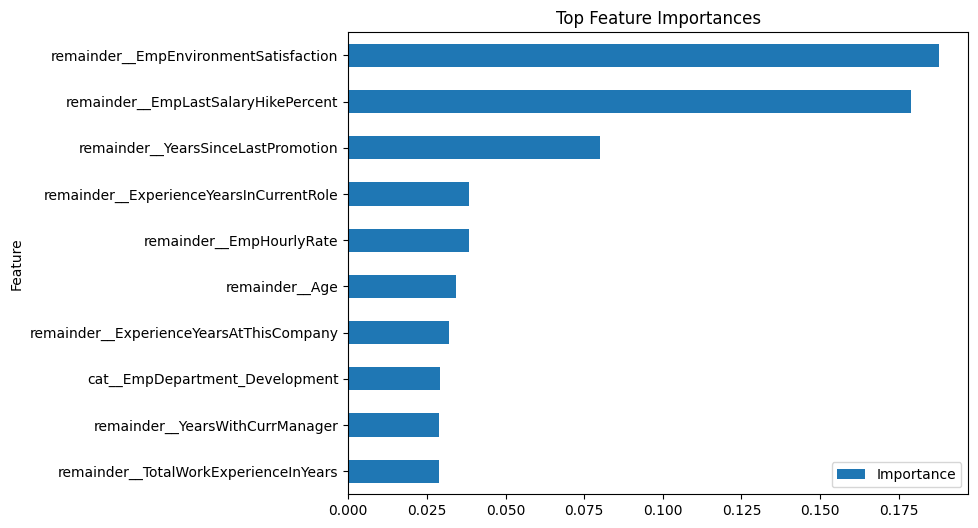

In [20]:
feat_imp.head(10).plot(
    kind='barh',
    x='Feature',
    y='Importance',
    figsize=(8,6)
)

plt.gca().invert_yaxis()
plt.title("Top Feature Importances")
plt.show()

In [21]:
top3 = feat_imp.head(3)
print(top3)

                                  Feature  Importance
38  remainder__EmpEnvironmentSatisfaction     0.18772
44    remainder__EmpLastSalaryHikePercent     0.17897
51     remainder__YearsSinceLastPromotion     0.07988


In [22]:
total_importance = feat_imp['Importance'].sum()

feat_imp['Percent_Contribution'] = (feat_imp['Importance'] / total_importance) * 100

top10 = feat_imp.head(10).copy()
top10['Cumulative_%'] = top10['Percent_Contribution'].cumsum()
top10



,Feature,Importance,Percent_Contribution,Cumulative_%
38,remainder__EmpEnvironmentSatisfaction,0.187720,18.772047,18.772047
44,remainder__EmpLastSalaryHikePercent,0.178970,17.897002,36.669049
51,remainder__YearsSinceLastPromotion,0.079880,7.988022,44.657071
50,remainder__ExperienceYearsInCurrentRole,0.038510,3.850989,48.508060
39,remainder__EmpHourlyRate,0.038498,3.849835,52.357896
35,remainder__Age,0.034244,3.424395,55.782291
49,remainder__ExperienceYearsAtThisCompany,0.031884,3.188352,58.970643
8,cat__EmpDepartment_Development,0.029150,2.915016,61.885659
52,remainder__YearsWithCurrManager,0.028903,2.890310,64.775969
46,remainder__TotalWorkExperienceInYears,0.028827,2.882692,67.658660


In [23]:
total_importance = feat_imp['Importance'].sum()

feat_imp['Percent_Contribution'] = (feat_imp['Importance'] / total_importance) * 100

bottom10 = feat_imp.tail(10).copy()
bottom10['Cumulative_%'] = bottom10['Percent_Contribution'].cumsum()
bottom10

,Feature,Importance,Percent_Contribution,Cumulative_%
4,cat__EducationBackground_Other,0.002136,0.213559,0.213559
18,cat__EmpJobRole_Human Resources,0.001842,0.184153,0.397713
17,cat__EmpJobRole_Healthcare Representative,0.001823,0.182332,0.580044
30,cat__EmpJobRole_Technical Lead,0.001304,0.130405,0.710449
22,cat__EmpJobRole_Manufacturing Director,0.001276,0.127618,0.838067
23,cat__EmpJobRole_Research Director,0.001198,0.119755,0.957822
28,cat__EmpJobRole_Senior Manager R&D,0.000681,0.068106,1.025928
13,cat__EmpJobRole_Data Scientist,0.000350,0.035029,1.060957
29,cat__EmpJobRole_Technical Architect,0.000048,0.004837,1.065794
14,cat__EmpJobRole_Delivery Manager,0.000019,0.001908,1.067702


In [24]:
Performance_dept = df.groupby('EmpDepartment')['PerformanceRating'].mean().sort_values(ascending=False)
Performance_dept

,PerformanceRating
EmpDepartment,
Development,3.085873
Data Science,3.050000
Human Resources,2.925926
Research & Development,2.921283
Sales,2.860590
Finance,2.775510


## **9.Insights**
These factors were found to have the highest contribution to predicting employee performance.

- To further appreciate the importance of features, it was discovered that the **top 3** features (mentioned above) contributed **44.65%** towards employee performance and the **top 10** features explain employee performance at **67.65%.**
- Education background and Job Rolescontributed to less than **10%** of the overall employee performance



## **10.Recommendation**

From the findings the following are recommended as possible intervntions to address the declining performance issue among employees;
- Conduct employment enviroment surveys to understand that the areas that need improvement
- Benchmark and design salary increment schemes/programmes that may not cause adverse effects to the financial performance of the Company
- Revisit the company promotion, awards and retention strategy and policy

## **11.Conclusion**

The project’s findings highlight the importance for INX Future Inc to adopt targeted interventions that foster a supportive work environment and ensure that employee contributions are appropriately recognized and rewarded.